# Titanic Survival Analysis

## Project Overview

The Titanic disaster is one of the most famous shipwrecks in history.

The goal of this analysis is to explore the factors that influenced passenger survival and identify patterns in the dataset before building machine learning models.

### Questions to Investigate

- Did gender affect survival?
- Did passenger class affect survival?
- Did age affect survival?
- Did ticket fare affect survival?
- Did family size affect survival?
- What characteristics were common among survivors?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore" , category=FutureWarning)

In [2]:
titanic_train = pd.read_csv("data/train (1).csv")
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

Before performing any analysis, we first inspect the structure of the dataset.

This includes:
- Number of rows and columns
- Data types
- Missing values
- Basic statistical information

Understanding the dataset helps identify potential cleaning and preprocessing tasks.

In [3]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
titanic_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
titanic_train.describe(include= "object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [6]:
titanic_train.isnull().sum().sort_values(ascending = False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [7]:
missing_percentage  = titanic_train.isna().mean() * 100 
missing_percentage[missing_percentage > 0].round(2).sort_values(ascending = False)

Cabin       77.10
Age         19.87
Embarked     0.22
dtype: float64

## Missing Values Analysis

Several columns contain missing values.

### Business Insight

- Age contains missing values and will require imputation.
- Embarked contains a small number of missing values.
- Cabin contains a large number of missing values.

Since Cabin has a very high percentage of missing values, it may not provide reliable information and will likely be removed.

In [8]:
titanic_train.drop(columns=["Cabin"] , inplace= True)

## Handling Missing Data

The Cabin feature was removed because more than 75% of its values were missing.

Keeping a feature with such a high proportion of missing data may introduce noise and reduce analysis quality.

In [9]:
titanic_train["Age"].fillna(titanic_train["Age"].median() , inplace = True)
titanic_train["Embarked"].fillna(titanic_train["Embarked"].mode()[0] , inplace=True)

## Age Imputation

Missing values in Age were replaced using the median age.

The median is preferred because age contains outliers and the median is more robust than the mean.

## Embarked Imputation

Missing values in Embarked were replaced using the mode value.

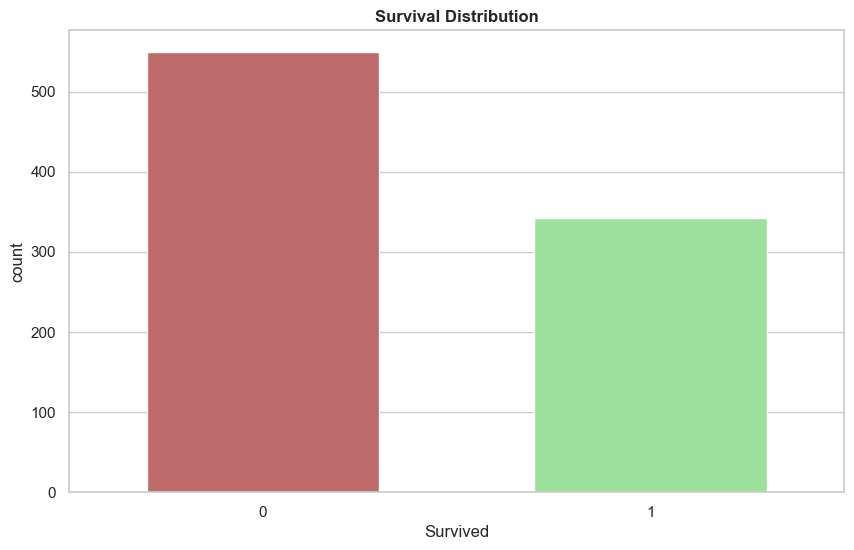

In [10]:
sns.set_theme(
    style= "whitegrid" , 
)
plt.figure(figsize=(10,6))
sns.countplot(data=titanic_train , x="Survived" , 
              palette= ["indianred","lightgreen"] , width=0.6)
plt.title("Survival Distribution",fontweight = "bold")
plt.show()

## Survival Distribution

### Business Insight

- The dataset contains more non-survivors than survivors.
- Survival was relatively rare during the disaster.
- This indicates a class imbalance that should be considered when building machine learning models.

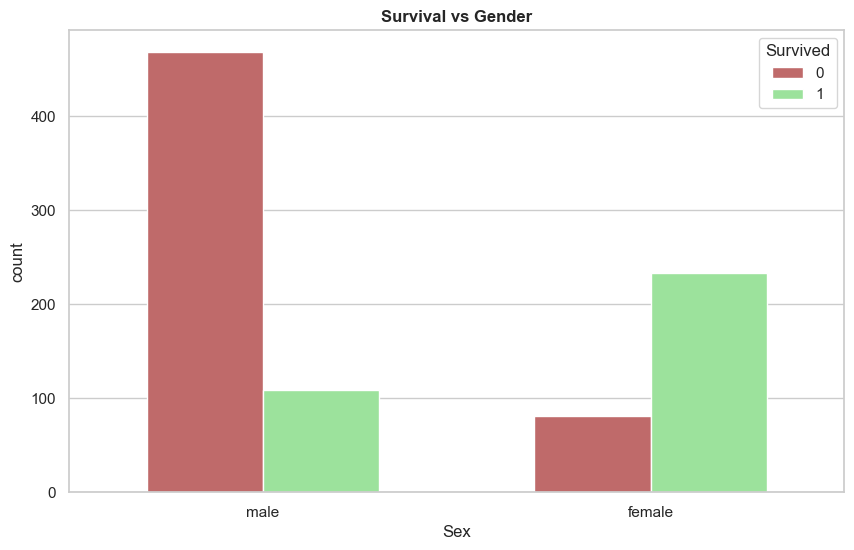

In [11]:
plt.figure(figsize=(10,6))
sns.countplot(data = titanic_train , x = "Sex" , hue = "Survived" , 
              palette= ["indianred","lightgreen"] ,width=0.6)
plt.title("Survival vs Gender",fontweight = "bold")
plt.show()

## Survival by Gender

### Business Insight

- Female passengers had significantly higher survival rates than male passengers.
- This supports the historical evacuation policy of "women and children first."
- Gender appears to be one of the strongest predictors of survival.

In [12]:
bins = [1,13,18,65,float("inf")]
labels = ["Child" ,"Teenager " , "Adult" , "Elderly"]

titanic_train["Age_category"] = pd.cut(titanic_train["Age"],
                                       bins= bins,
                                       labels= labels)

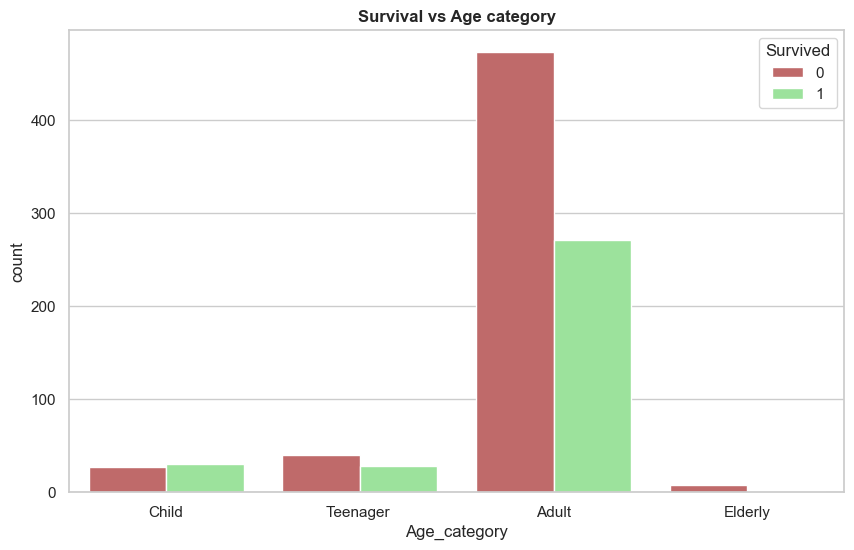

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data = titanic_train , x="Age_category" , 
              hue= "Survived" , palette=["indianred","lightgreen"])
plt.title("Survival vs Age category",fontweight = "bold")
plt.show()

## Survival by Age

### Business Insight

- Most passengers were adults.
- A small number of elderly passengers are present.
- Younger passengers generally had higher survival rates.
- Children appear to have been prioritized during evacuation.
- Survival tends to decrease among older age groups.

Age appears to be a meaningful factor in survival outcomes.
The presence of extreme ages suggests that age may contain outliers.

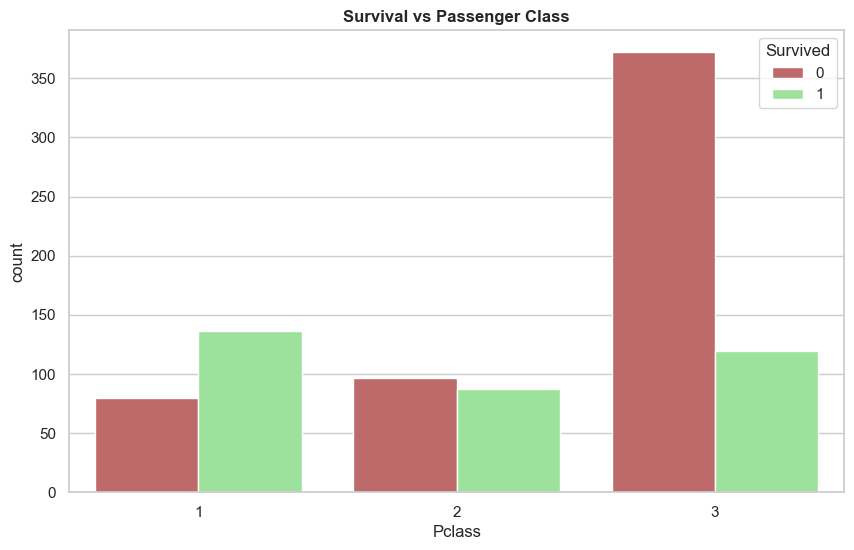

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(data = titanic_train , x="Pclass" , 
              hue = "Survived" , palette=["indianred","lightgreen"])
plt.title("Survival vs Passenger Class" , fontweight = "bold")
plt.savefig("Survival vs Passenger Class.jpg")
plt.show()

## Survival by Passenger Class

### Business Insight

- First-class passengers had the highest survival rates.
- Third-class passengers had the lowest survival rates.
- Passenger class appears to have played an important role during evacuation.

Possible explanation:
First-class passengers had better access to lifeboats and evacuation routes.

<Figure size 1000x600 with 0 Axes>

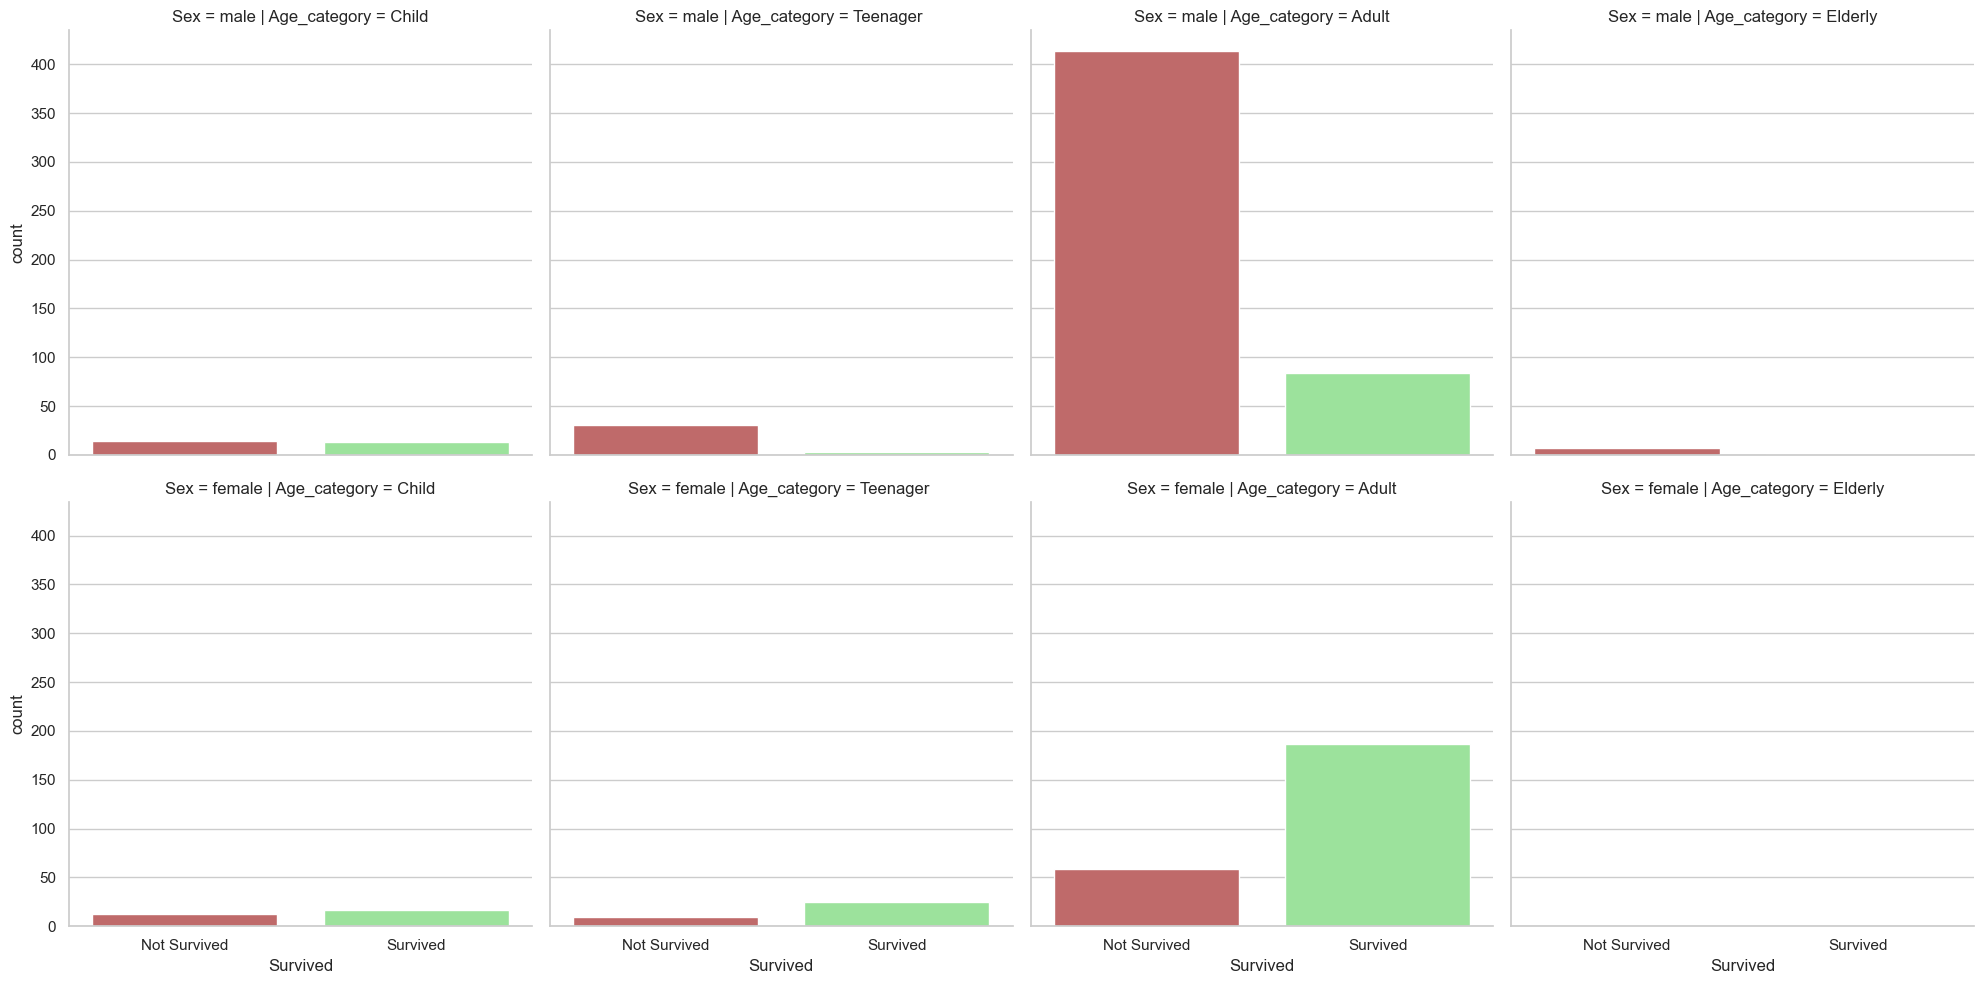

In [15]:
plt.figure(figsize=(10,6))
sns.catplot(data = titanic_train , x = "Survived" , 
            kind = "count" , row = "Sex" , col = "Age_category" , palette=["indianred","lightgreen"])
plt.xticks(ticks=[0,1] , labels= ["Not Survived" , "Survived"])
plt.savefig("Survived Vs Sex & Agecategory.jpg")
plt.show()

## CatPlot Insights (Survived vs Sex & Age Category)

The catplot shows the relationship between survival, gender, and age category.

- Gender is the most important factor affecting survival. Females had a much higher       survival rate compared to males across all age categories.
- Children generally had better survival chances than adults, especially female children.
- Adult males show the lowest survival rate, with most of them not surviving.
- Age has an effect, but it is weaker compared to gender.
- Overall, survival was highly influenced by gender, with age acting as a secondary factor.

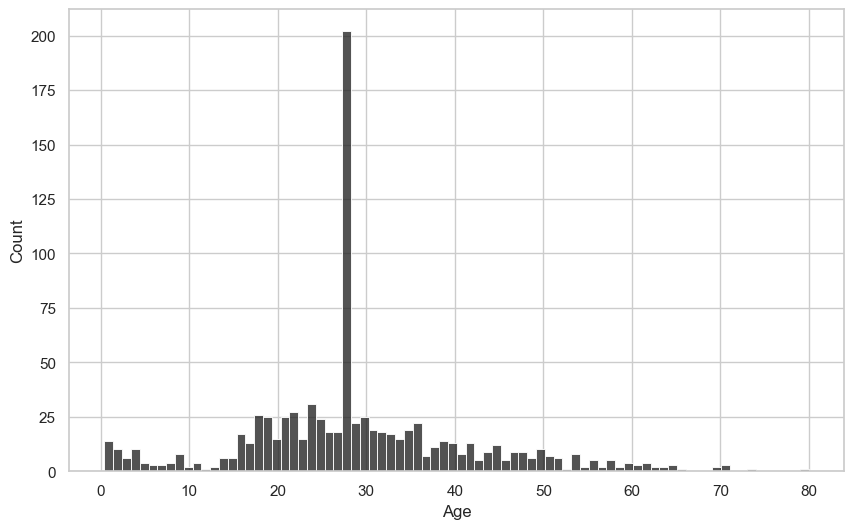

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data=titanic_train , x="Age" , binwidth=1 , color="k")
plt.show()

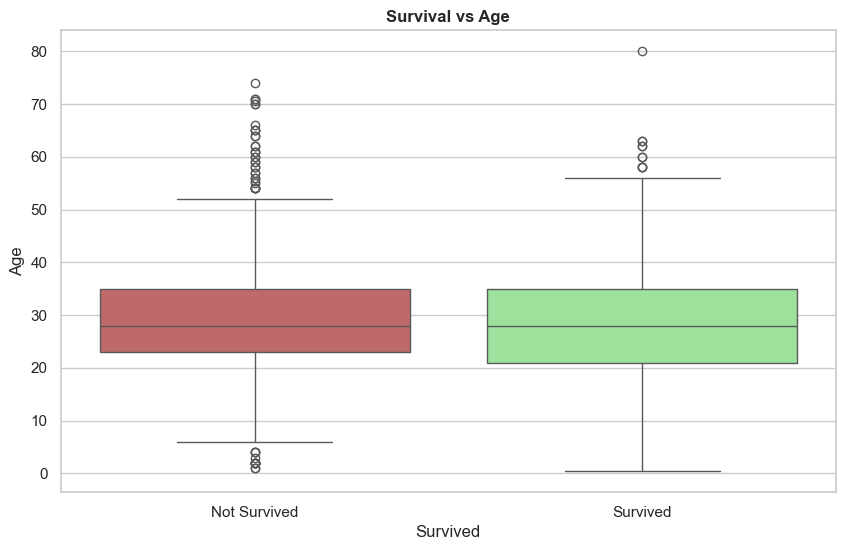

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data = titanic_train , x="Survived" , y="Age" ,  palette=["indianred","lightgreen"])
plt.xticks(ticks=[0,1] , labels= ["Not Survived" , "Survived"])
plt.title("Survival vs Age",fontweight = "bold")
plt.show()

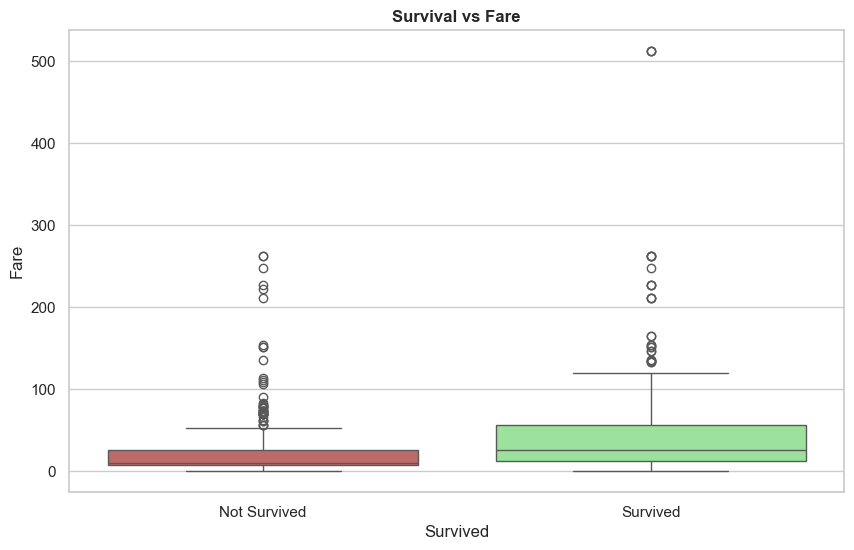

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=titanic_train , x="Survived" , y="Fare" ,palette=["indianred","lightgreen"])
plt.xticks(ticks=[0,1] , labels= ["Not Survived" , "Survived"])
plt.title("Survival vs Fare",fontweight = "bold")
plt.show()

## Survival by Fare

### Business Insight

- Passengers who paid higher fares generally had better survival rates.
- Higher fares are strongly associated with higher passenger classes.
- Wealthier passengers may have had better access to rescue opportunities.
- Most passengers paid relatively low fares.

These high-fare observations appear as outliers.

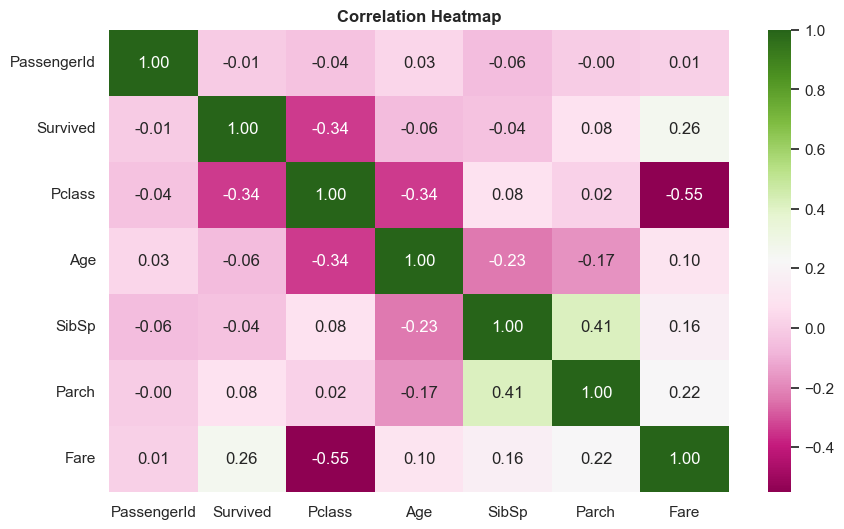

In [19]:
corr = titanic_train.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr , annot=True , fmt=".2f" ,cmap="PiYG")
plt.title("Correlation Heatmap",fontweight = 'bold')
plt.savefig("Heatmap.jpg")
plt.show()

## Correlation Analysis

### Business Insight

- Fare and passenger class show a strong relationship.
- Survival is positively associated with fare.
- Survival is negatively associated with passenger class number.

No extremely strong correlations exist among most variables, indicating that multiple factors contributed to survival.

<Figure size 1000x600 with 0 Axes>

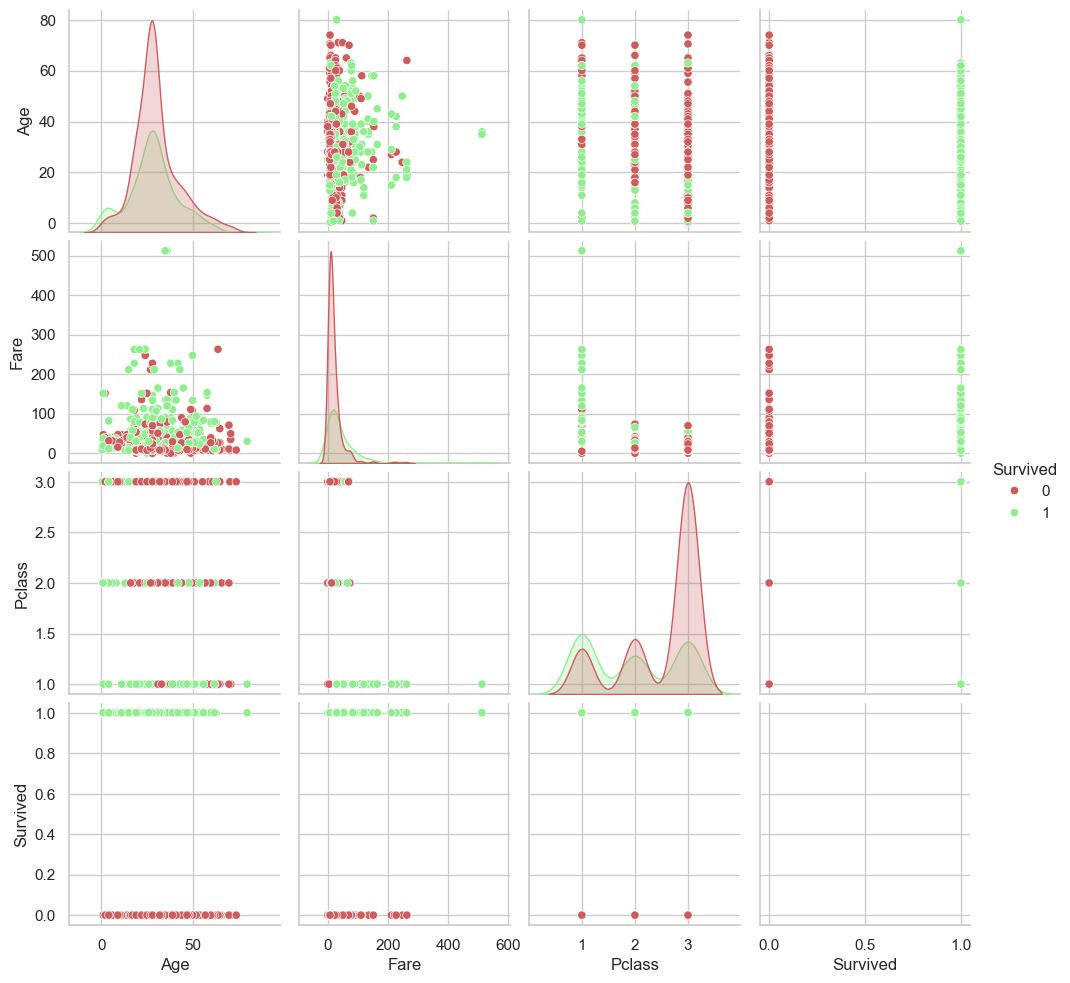

In [20]:
plt.figure(figsize=(10,6))
sns.pairplot(titanic_train, hue="Survived",vars= ["Age","Fare","Pclass","Survived"]
            ,palette=["indianred","lightgreen"])
plt.savefig("pair plot.jpg")
plt.show()

## PairPlot Insights (Age, Fare, Pclass vs Survived)

The pairplot explores the relationship between numerical features and survival.

- Passengers who paid higher fares had a higher chance of survival.
- First-class passengers (lower Pclass values) are more likely to survive, while third-   class passengers are mostly in the non-survived group.
- Age shows a weak relationship with survival, with no clear separation, although         children appear slightly more in the survived group.
- There is a strong relationship between Pclass and Fare, where higher classes            correspond to higher fares.
- Overall, survival is strongly associated with socio-economic status (Pclass and Fare), while age has a weaker effect.

In [21]:
titanic_train["Family_size"] = titanic_train["SibSp"] + titanic_train["Parch"] + 1
titanic_train["IsAlone"] = (titanic_train["Family_size"] == 1).astype(int)

## Feature Engineering: Family Size

A new feature called Family Size was created:

Family Size = SibSp + Parch + 1

This feature represents the total number of family members traveling together, including the passenger.

## Feature Engineering: IsAlone

A binary feature was created to identify passengers traveling alone.

This may help determine whether social support during evacuation influenced survival.

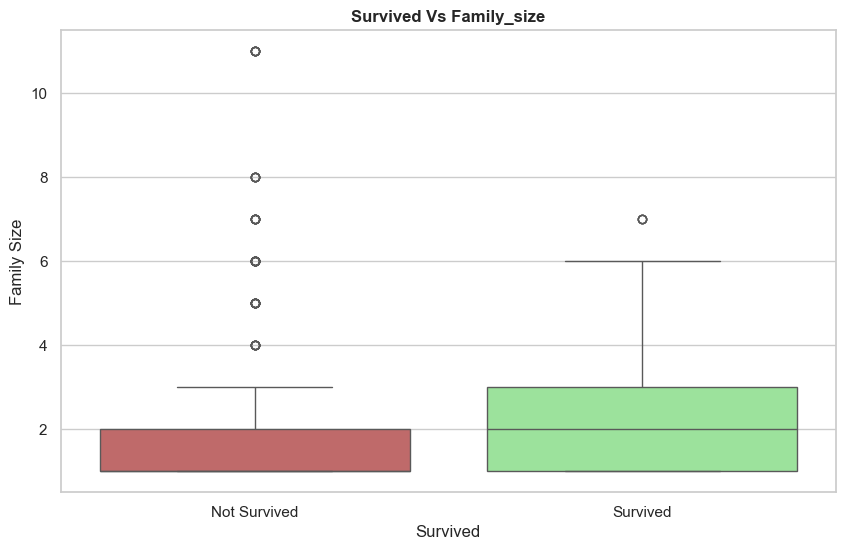

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=titanic_train , x="Survived" , y="Family_size",palette=["indianred","lightgreen"])
plt.xticks(ticks=[0,1] , labels= ["Not Survived" , "Survived"])
plt.title("Survived Vs Family_size",fontweight = 'bold')
plt.ylabel("Family Size")
plt.savefig("Survived Vs Family_size.jpg")
plt.show()

## Survival by Family Size

### Business Insight

- Passengers traveling with very large families had lower survival rates.
- Passengers traveling completely alone also experienced lower survival rates.
- Small and moderate-sized families appear to have had better survival chances.

This suggests that family size may influence evacuation outcomes.

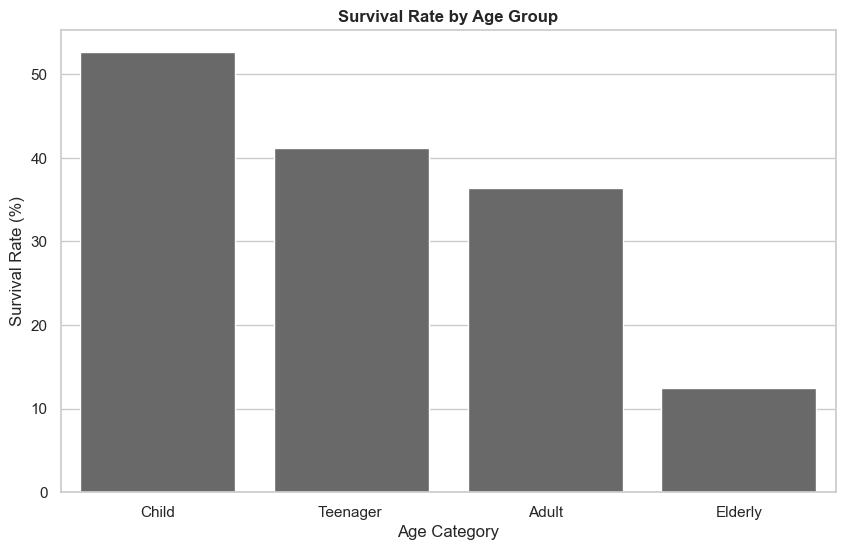

In [23]:
titanic_train["survival_rate"] = titanic_train.groupby("Age_category")["Survived"].transform("mean")*100
plt.figure(figsize=(10,6))
sns.barplot(data=titanic_train , x="Age_category" , y="survival_rate",color="dimgrey")
plt.title("Survival Rate by Age Group" ,fontweight = 'bold')
plt.ylabel("Survival Rate (%)")
plt.xlabel("Age Category")
plt.savefig("Survival Rate by Age Group.jpg")
plt.show()

# Final Conclusions

After performing exploratory data analysis, several important factors influencing survival were identified.

Survival in the Titanic dataset was not random. It was mainly influenced by gender and passenger class, where females and first-class passengers had significantly higher survival rates. Age played a smaller role compared to these dominant factors.

## Key Findings

1. Female passengers had significantly higher survival rates than males.

2. First-class passengers were more likely to survive than second- and third-class passengers.

3. Younger passengers generally experienced better survival outcomes.

4. Higher ticket fares were associated with higher survival rates.

5. Family size influenced survival, with small families showing better outcomes than very large families or solo travelers.

6. Passenger class, fare, gender, age, and family-related features all appear to be important predictors of survival.

## Next Steps

The next phase of this project will focus on:

- Data preprocessing for machine learning
- Feature encoding
- Model training
- Model evaluation
- Survival prediction